# Comparison of CNN Inference with Charge Barycenter using BFM

In [1]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.optimize import curve_fit
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
from datetime import datetime
import os

# Output directory with timestamp
_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
FIG_DIR = f"/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/figures_{_ts}"
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}")

Figures will be saved to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/figures_20260420_122937


## Load Files

### Matching File (BFM)

In [3]:
file = uproot.open("/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/tpcpmtmatching/tpcpmtbarycentermatching_hist.root")

tree = file['tpcpmtbarycentermatchingSCE/matchTree;1']
print(f"Entries: {tree.num_entries}")

Entries: 56418


### Inference File (CNN)

In [4]:
file2 = uproot.open("/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_Final_Wrapup/position_DATA/BFM/resnet_inference/2000/ttree_analysis_PosRecoCVNProd-20260420T103037.root")

tree2 = file2['ResNetInference/inference_tree']
print(f"Entries: {tree2.num_entries}")

df_inference = tree2.arrays(library='pd')
n_total_inf = len(df_inference)
df_inference = df_inference[df_inference['passed_filters'] == True].reset_index(drop=True)
print(f"Inference events passing filters: {len(df_inference)} / {n_total_inf} ({100*len(df_inference)/n_total_inf:.1f}%)")
df_inference = df_inference.drop(columns=['subrun', 'passed_filters'])
print(f"Columns: {list(df_inference.columns)}")
df_inference.head()

Entries: 2000
Inference events passing filters: 1845 / 2000 (92.2%)
Columns: ['run', 'event', 'pred_x', 'pred_y', 'pred_z', 'selected_tpc', 'pred_dir_y', 'pred_dir_z']


,run,event,pred_x,pred_y,pred_z,selected_tpc,pred_dir_y,pred_dir_z
0,18253,483289,124.95,-182.46,364.94,0,-0.18,0.98
1,18253,483619,62.62,193.96,461.80,0,0.49,0.87
2,18253,483861,149.22,-28.82,333.83,1,0.29,0.96
3,18253,484147,161.57,-192.79,104.59,0,-0.13,0.99
4,18253,484191,121.16,-85.33,194.28,0,0.61,0.80


In [5]:
# Load BFM data and remove unnecessary columns
df = tree.arrays(library='pd')

columns_to_remove = [
    'deltaZ_Trigger', 'deltaY_Trigger', 'radius_Trigger',  # Trigger metrics
    'chargeWidthX', 'chargeWidthY', 'chargeWidthZ',        # Charge widths
    'flashWidthY', 'flashWidthZ',                          # Flash widths
    'chargeT0', 'deltaT'                                   # Always -9999
]

df = df.drop(columns=columns_to_remove)

print(f"Columns: {len(df.columns)} | Unique events: {df['event'].nunique()} | Unique runs: {df['run'].nunique()}")

Columns: 20 | Unique events: 2000 | Unique runs: 6


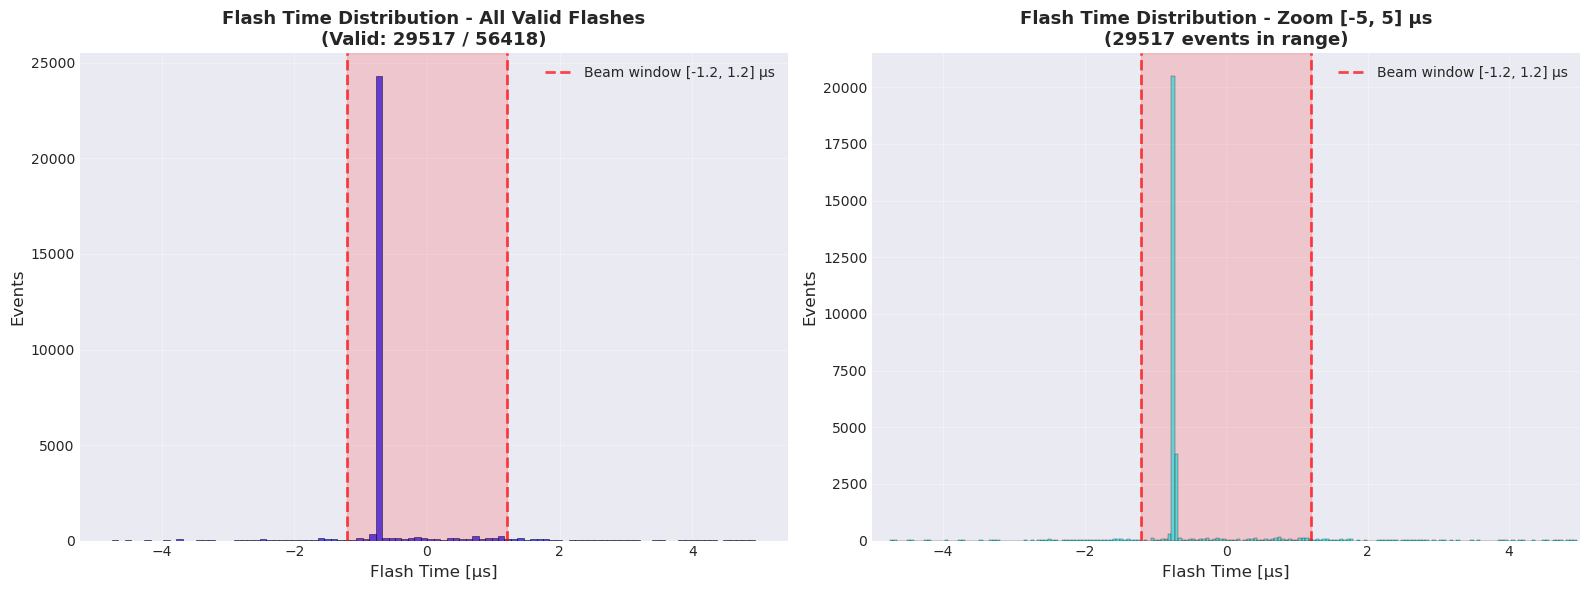

                         FLASH TIME STATISTICS

Total entries:                56418
Valid flashes:                29517 (52.3%)
Invalid entries:              26901 (47.7%)

Statistic                                Value
--------------------------------------------------------------------------------
Mean                                     -0.59 μs
Std                                       0.80 μs
Median                                   -0.74 μs
Min                                      -4.75 μs
Max                                       4.95 μs

Window                                   Count      Percentage
--------------------------------------------------------------------------------
In beam window [-1.2, 1.2]               27384           92.8%
In old window [-2, 2]                    28478           96.5%
In zoom region [-5, 5]                   29517          100.0%
Outside beam window                       2133            7.2%

Region around beam window                Count     

In [6]:
# Flash time analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Filter invalid values (-9999 and -10000)
flash_times = df['flashTime']
flash_times_valid = flash_times[(flash_times != -9999) & (flash_times != -10000)]

# Plot 1: All valid flashes (without invalid values)
ax = axes[0]
ax.hist(flash_times_valid, bins=100, alpha=0.7, color='blue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Flash Time [μs]', fontsize=12)
ax.set_ylabel('Events', fontsize=12)
ax.set_title(f'Flash Time Distribution - All Valid Flashes\n(Valid: {len(flash_times_valid)} / {len(flash_times)})', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Vertical lines for beam window
ax.axvline(-1.2, color='red', linestyle='--', linewidth=2, label='Beam window [-1.2, 1.2] μs', alpha=0.7)
ax.axvline(1.2, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.axvspan(-1.2, 1.2, alpha=0.15, color='red')

ax.legend(fontsize=10)

# Plot 2: Zoom in region [-5, 5] showing window [-1.2, 1.2]
ax = axes[1]
flash_times_zoom = flash_times_valid[(flash_times_valid >= -5) & (flash_times_valid <= 5)]
ax.hist(flash_times_zoom, bins=200, alpha=0.7, color='cyan', edgecolor='black', linewidth=0.3)
ax.set_xlabel('Flash Time [μs]', fontsize=12)
ax.set_ylabel('Events', fontsize=12)
ax.set_title(f'Flash Time Distribution - Zoom [-5, 5] μs\n({len(flash_times_zoom)} events in range)', 
             fontsize=13, fontweight='bold')
ax.set_xlim(-5, 5)
ax.grid(True, alpha=0.3)

# Vertical lines for beam window [-1.2, 1.2]
ax.axvline(-1.2, color='red', linestyle='--', linewidth=2, label='Beam window [-1.2, 1.2] μs', alpha=0.7)
ax.axvline(1.2, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.axvspan(-1.2, 1.2, alpha=0.15, color='red')

ax.legend(fontsize=10)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/flash_time_distribution.png", dpi=150, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/flash_time_distribution.pdf", bbox_inches='tight')
plt.show()

# Statistics
print("="*80)
print(" "*25 + "FLASH TIME STATISTICS")
print("="*80)
print(f"\nTotal entries:                {len(flash_times)}")
print(f"Valid flashes:                {len(flash_times_valid)} ({100*len(flash_times_valid)/len(flash_times):.1f}%)")
print(f"Invalid entries:              {len(flash_times) - len(flash_times_valid)} ({100*(len(flash_times) - len(flash_times_valid))/len(flash_times):.1f}%)")

print(f"\n{'Statistic':30s} {'Value':>15s}")
print("-"*80)
print(f"{'Mean':30s} {flash_times_valid.mean():>15.2f} μs")
print(f"{'Std':30s} {flash_times_valid.std():>15.2f} μs")
print(f"{'Median':30s} {flash_times_valid.median():>15.2f} μs")
print(f"{'Min':30s} {flash_times_valid.min():>15.2f} μs")
print(f"{'Max':30s} {flash_times_valid.max():>15.2f} μs")

# Count flashes in different windows and regions
in_beam_window = ((flash_times_valid >= -1.2) & (flash_times_valid <= 1.2)).sum()
in_old_window = ((flash_times_valid >= -2.0) & (flash_times_valid <= 2.0)).sum()
in_zoom_region = ((flash_times_valid >= -5.0) & (flash_times_valid <= 5.0)).sum()
outside_beam = len(flash_times_valid) - in_beam_window

print(f"\n{'Window':30s} {'Count':>15s} {'Percentage':>15s}")
print("-"*80)
print(f"{'In beam window [-1.2, 1.2]':30s} {in_beam_window:>15d} {100*in_beam_window/len(flash_times_valid):>14.1f}%")
print(f"{'In old window [-2, 2]':30s} {in_old_window:>15d} {100*in_old_window/len(flash_times_valid):>14.1f}%")
print(f"{'In zoom region [-5, 5]':30s} {in_zoom_region:>15d} {100*in_zoom_region/len(flash_times_valid):>14.1f}%")
print(f"{'Outside beam window':30s} {outside_beam:>15d} {100*outside_beam/len(flash_times_valid):>14.1f}%")

# Distribution around beam window
print(f"\n{'Region around beam window':30s} {'Count':>15s} {'Percentage':>15s}")
print("-"*80)
regions = [
    ("< -5 μs", (flash_times_valid < -5)),
    ("[-5, -1.2) μs", (flash_times_valid >= -5) & (flash_times_valid < -1.2)),
    ("[-1.2, 1.2] μs (BEAM)", (flash_times_valid >= -1.2) & (flash_times_valid <= 1.2)),
    ("(0.4, 5] μs", (flash_times_valid > 1.2) & (flash_times_valid <= 5)),
    ("> 5 μs", (flash_times_valid > 5)),
]

for name, mask in regions:
    count = mask.sum()
    print(f"{name:30s} {count:>15d} {100*count/len(flash_times_valid):>14.1f}%")

print("="*80)

In [7]:
score_min   = 0.1
nuScore_min = 0.5
beam_window = (-1.2, 1.2)  # us

n_bfm = len(df)
n_score   = (df['score']   > score_min).sum()
n_nuscore = ((df['score']  > score_min) & (df['nuScore'] > nuScore_min)).sum()

df_cut = df[
    (df['score']     > score_min) &
    (df['nuScore']   > nuScore_min) &
    (df['flashTime'] > beam_window[0]) &
    (df['flashTime'] < beam_window[1])
]
n_cut = len(df_cut)

print('=' * 62)
print('CUT FLOW — BFM selection')
print('=' * 62)
print(f'  score > {score_min},  nuScore > {nuScore_min},  beam: {beam_window} us')
print('-' * 62)
print(f'  Total BFM entries:         {n_bfm:6d}')
print(f'  After score > {score_min}:        {n_score:6d}  ({100*n_score/n_bfm:.1f}%)')
print(f'  After nuScore > {nuScore_min}:     {n_nuscore:6d}  ({100*n_nuscore/n_bfm:.1f}%)')
print(f'  After beam window:         {n_cut:6d}  ({100*n_cut/n_bfm:.1f}%)')
print('=' * 62)

CUT FLOW — BFM selection
  score > 0.1,  nuScore > 0.5,  beam: (-1.2, 1.2) us
--------------------------------------------------------------
  Total BFM entries:          56418
  After score > 0.1:          1177  (2.1%)
  After nuScore > 0.5:        627  (1.1%)
  After beam window:            611  (1.1%)


## Comparison: Merge Inference with BFM Cuts

In [8]:
# Merge df_cut with df_inference using run and event
df_comparison = df_cut.merge(
    df_inference[['run', 'event', 'pred_x', 'pred_y', 'pred_z', 'selected_tpc', 'pred_dir_y', 'pred_dir_z']],
    on=['run', 'event'],
    how='left'
)

n_after_merge = len(df_comparison)
print(f"Total entries (rows): {n_after_merge}")
initial_unique_events = df_comparison['event'].nunique()
print(f"Unique events: {initial_unique_events}")

# FIRST FILTER: Count how many events have multiple slices
event_counts = df_comparison.groupby(['run', 'event']).size()
events_multiple = event_counts[event_counts > 1]

if len(events_multiple) > 0:
    events_to_remove = events_multiple.index.tolist()
    mask = df_comparison.apply(lambda row: (row['run'], row['event']) not in events_to_remove, axis=1)
    df_comparison = df_comparison[mask]
    print(f"  Multi-slice events removed: {len(events_multiple)} ({100*len(events_multiple)/initial_unique_events:.1f}%)")
else:
    print("  No multi-slice events")

n_after_dedup = len(df_comparison)

# Apply absolute value to X coordinates (for fair comparison with CNN)
df_comparison['chargeCenterX_abs'] = df_comparison['chargeCenterXGlobal'].abs()
df_comparison['flashCenterX_abs'] = df_comparison['flashCenterX'].abs()

Total entries (rows): 611
Unique events: 550
  Multi-slice events removed: 61 (11.1%)


In [9]:
# Second filter: Remove events where cryo != selected_tpc
# (where BFM and CNN disagree on TPC assignment)

print("="*80)
print(" "*15 + "SECOND FILTER: BFM-CNN TPC AGREEMENT")
print("="*80)

# Count events before filter
events_before = len(df_comparison)
print(f"\nEvents before filter: {events_before}")

# Identify events where cryo != selected_tpc
mismatch_tpc = df_comparison['cryo'] != df_comparison['selected_tpc']
mismatch_events = mismatch_tpc.sum()

print(f"Events where cryo ≠ selected_tpc: {mismatch_events} ({mismatch_events/events_before*100:.1f}%)")
print(f"Events where cryo = selected_tpc: {events_before - mismatch_events} ({(events_before - mismatch_events)/events_before*100:.1f}%)")

# Show some examples of mismatch events
if mismatch_events > 0:
    print(f"\nExamples of mismatch events (first 5):")
    print("-"*80)
    df_mismatch = df_comparison[mismatch_tpc].head()
    print(df_mismatch[['run', 'event', 'cryo', 'selected_tpc', 'score', 'nuScore']].to_string(index=False))

# Apply filter: keep only events where cryo == selected_tpc
df_comparison_filtered = df_comparison[df_comparison['cryo'] == df_comparison['selected_tpc']].copy()

removed_percentage = 100 * mismatch_events / events_before

print(f"\n" + "-"*80)
print(f"AFTER FILTER:")
print(f"  Events remaining: {len(df_comparison_filtered)}")
print(f"  Events removed: {mismatch_events} ({removed_percentage:.1f}%)")
print("="*80)

# Update df_valid with filtered data
df_valid = df_comparison_filtered

               SECOND FILTER: BFM-CNN TPC AGREEMENT

Events before filter: 489
Events where cryo ≠ selected_tpc: 28 (5.7%)
Events where cryo = selected_tpc: 461 (94.3%)

Examples of mismatch events (first 5):
--------------------------------------------------------------------------------
  run  event  cryo  selected_tpc  score  nuScore
18253 500063     1           NaN   0.12     0.57
18253 502989     1           NaN   0.36     0.52
18253 503539     0           NaN   0.28     0.50
18253 485600     1           NaN   0.14     0.63
18253 487668     1           NaN   0.52     0.56

--------------------------------------------------------------------------------
AFTER FILTER:
  Events remaining: 461
  Events removed: 28 (5.7%)


In [10]:
# Full cut flow summary
print('=' * 62)
print('FULL CUT FLOW SUMMARY')
print('=' * 62)
print(f'  BFM total entries:              {n_bfm:6d}')
print(f'  After BFM quality cuts:         {n_cut:6d}  ({100*n_cut/n_bfm:.1f}%)')
print(f'  After merge with inference:     {n_after_merge:6d}  ({100*n_after_merge/n_bfm:.1f}%)')
print(f'  After removing multi-slice:     {n_after_dedup:6d}  ({100*n_after_dedup/n_bfm:.1f}%)')
print(f'  After TPC agreement (df_valid): {len(df_valid):6d}  ({100*len(df_valid)/n_bfm:.1f}%)')
print('=' * 62)

FULL CUT FLOW SUMMARY
  BFM total entries:               56418
  After BFM quality cuts:            611  (1.1%)
  After merge with inference:        611  (1.1%)
  After removing multi-slice:        489  (0.9%)
  After TPC agreement (df_valid):    461  (0.8%)


### Plots

### Random event visualization

Showing 10 random events


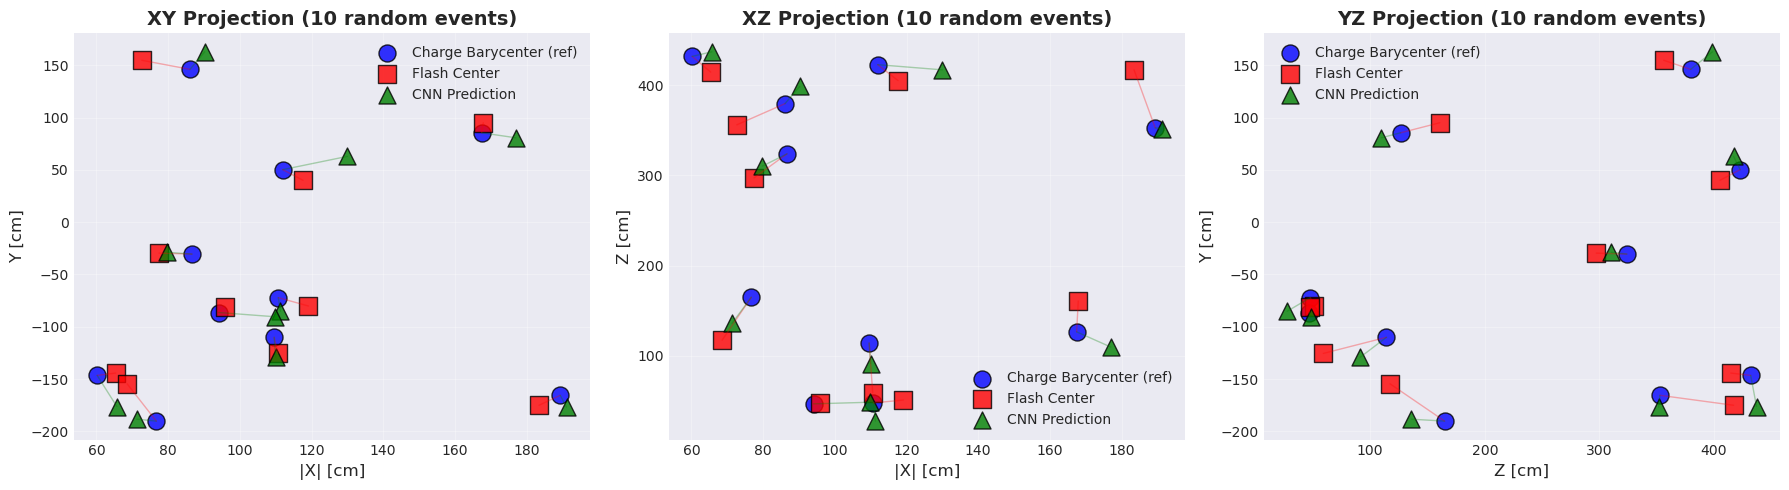

In [11]:
# Plot with connections between methods for the same event
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Select 10 random events
df_plot = df_valid.sample(n=10, random_state=185)

print(f"Showing 10 random events")

# For each valid entry, draw lines from Charge Barycenter to Flash and CNN
for idx, row in df_plot.iterrows():
    # XY projection: lines from Charge Barycenter
    axes[0].plot([row['chargeCenterX_abs'], row['flashCenterX_abs']], 
                 [row['chargeCenterY'], row['flashCenterY']], 
                 'r-', alpha=0.3, linewidth=1)  # Charge -> Flash
    axes[0].plot([row['chargeCenterX_abs'], row['pred_x']], 
                 [row['chargeCenterY'], row['pred_y']], 
                 'g-', alpha=0.3, linewidth=1)  # Charge -> CNN
    
    # XZ projection: lines from Charge Barycenter
    axes[1].plot([row['chargeCenterX_abs'], row['flashCenterX_abs']], 
                 [row['chargeCenterZ'], row['flashCenterZ']], 
                 'r-', alpha=0.3, linewidth=1)  # Charge -> Flash
    axes[1].plot([row['chargeCenterX_abs'], row['pred_x']], 
                 [row['chargeCenterZ'], row['pred_z']], 
                 'g-', alpha=0.3, linewidth=1)  # Charge -> CNN
    
    # YZ projection: lines from Charge Barycenter
    axes[2].plot([row['chargeCenterZ'], row['flashCenterZ']], 
                 [row['chargeCenterY'], row['flashCenterY']], 
                 'r-', alpha=0.3, linewidth=1)  # Charge -> Flash
    axes[2].plot([row['chargeCenterZ'], row['pred_z']], 
                 [row['chargeCenterY'], row['pred_y']], 
                 'g-', alpha=0.3, linewidth=1)  # Charge -> CNN

# Plot XY
ax = axes[0]
ax.scatter(df_plot['chargeCenterX_abs'], df_plot['chargeCenterY'], 
           s=150, alpha=0.8, marker='o', label='Charge Barycenter (ref)', color='blue', edgecolors='black', linewidths=1)
ax.scatter(df_plot['flashCenterX_abs'], df_plot['flashCenterY'], 
           s=150, alpha=0.8, marker='s', label='Flash Center', color='red', edgecolors='black', linewidths=1)
ax.scatter(df_plot['pred_x'], df_plot['pred_y'], 
           s=150, alpha=0.8, marker='^', label='CNN Prediction', color='green', edgecolors='black', linewidths=1)
ax.set_xlabel('|X| [cm]', fontsize=12)
ax.set_ylabel('Y [cm]', fontsize=12)
ax.set_title('XY Projection (10 random events)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot XZ
ax = axes[1]
ax.scatter(df_plot['chargeCenterX_abs'], df_plot['chargeCenterZ'], 
           s=150, alpha=0.8, marker='o', label='Charge Barycenter (ref)', color='blue', edgecolors='black', linewidths=1)
ax.scatter(df_plot['flashCenterX_abs'], df_plot['flashCenterZ'], 
           s=150, alpha=0.8, marker='s', label='Flash Center', color='red', edgecolors='black', linewidths=1)
ax.scatter(df_plot['pred_x'], df_plot['pred_z'], 
           s=150, alpha=0.8, marker='^', label='CNN Prediction', color='green', edgecolors='black', linewidths=1)
ax.set_xlabel('|X| [cm]', fontsize=12)
ax.set_ylabel('Z [cm]', fontsize=12)
ax.set_title('XZ Projection (10 random events)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot YZ
ax = axes[2]
ax.scatter(df_plot['chargeCenterZ'], df_plot['chargeCenterY'], 
           s=150, alpha=0.8, marker='o', label='Charge Barycenter (ref)', color='blue', edgecolors='black', linewidths=1)
ax.scatter(df_plot['flashCenterZ'], df_plot['flashCenterY'], 
           s=150, alpha=0.8, marker='s', label='Flash Center', color='red', edgecolors='black', linewidths=1)
ax.scatter(df_plot['pred_z'], df_plot['pred_y'], 
           s=150, alpha=0.8, marker='^', label='CNN Prediction', color='green', edgecolors='black', linewidths=1)
ax.set_xlabel('Z [cm]', fontsize=12)
ax.set_ylabel('Y [cm]', fontsize=12)
ax.set_title('YZ Projection (10 random events)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/connections_plot.png", dpi=150, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/connections_plot.pdf", bbox_inches='tight')
plt.show()

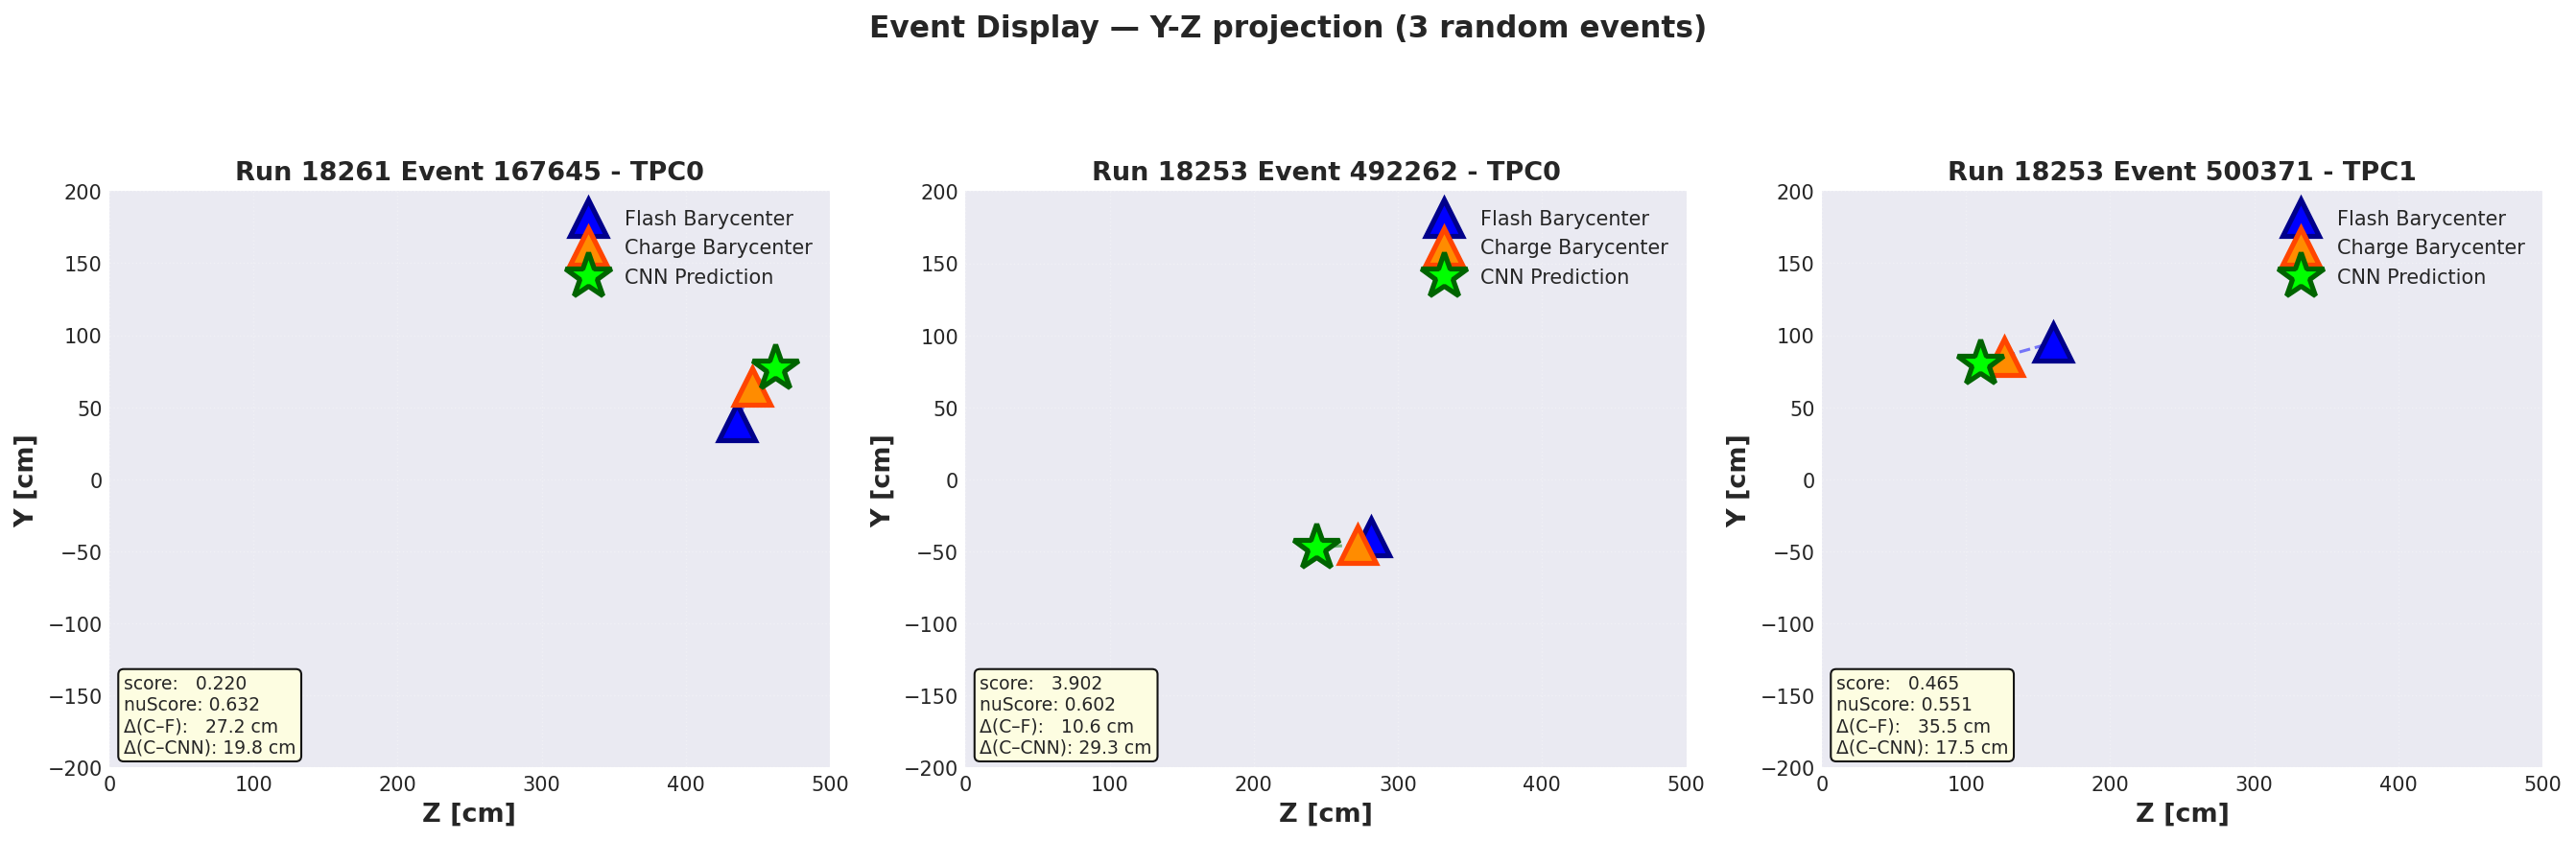

Blue triangle  = Flash Barycenter
Orange triangle = Charge Barycenter
Green star      = CNN Prediction


In [12]:
# Event display: Y-Z projection for 3 random events
# Shows Flash Barycenter, Charge Barycenter, and CNN Prediction
import random
random.seed(1234567)
sample_idx = random.sample(list(df_valid.index), min(3, len(df_valid)))
df_evt = df_valid.loc[sample_idx]

fig, axes = plt.subplots(1, len(df_evt), figsize=(6*len(df_evt), 6), dpi=150)
if len(df_evt) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, df_evt.iterrows()):
    cy, cz = row['chargeCenterY'], row['chargeCenterZ']
    fy, fz = row['flashCenterY'],  row['flashCenterZ']
    py, pz = row['pred_y'],        row['pred_z']

    # Connecting lines
    ax.plot([cz, fz], [cy, fy], 'b--', alpha=0.5, lw=1.5)
    ax.plot([cz, pz], [cy, py], 'g--', alpha=0.5, lw=1.5)

    # Markers
    ax.plot(fz, fy, '^', color='blue',       markersize=18, label='Flash Barycenter',
            markeredgecolor='darkblue',   markeredgewidth=2.5, zorder=10)
    ax.plot(cz, cy, '^', color='darkorange', markersize=18, label='Charge Barycenter',
            markeredgecolor='orangered',  markeredgewidth=2.5, zorder=10)
    ax.plot(pz, py, '*', color='lime',       markersize=24, label='CNN Prediction',
            markeredgecolor='darkgreen',  markeredgewidth=2.5, zorder=11)

    # Distances
    d_cf = np.sqrt((cy - fy)**2 + (cz - fz)**2)
    d_cp = np.sqrt((cy - py)**2 + (cz - pz)**2)
    info = (f'score:   {row["score"]:.3f}\n'
            f'nuScore: {row["nuScore"]:.3f}\n'
            f'\u0394(C\u2013F):   {d_cf:.1f} cm\n'
            f'\u0394(C\u2013CNN): {d_cp:.1f} cm')
    ax.text(0.02, 0.02, info, transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.92))

    # Styling
    ax.set_xlabel('Z [cm]', fontsize=13, fontweight='bold')
    ax.set_ylabel('Y [cm]', fontsize=13, fontweight='bold')
    ax.set_title(f'Run {int(row["run"])} Event {int(row["event"])} - TPC{int(row["cryo"])}',
                 fontsize=13, fontweight='bold')
    ax.set_xlim(0, 500)
    ax.set_ylim(-200, 200)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.7)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(),
              fontsize=10, loc='upper right', framealpha=0.95)

plt.suptitle('Event Display — Y-Z projection (3 random events)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/event_display_yz.png", dpi=150, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/event_display_yz.pdf", bbox_inches='tight')
plt.show()

print('Blue triangle  = Flash Barycenter')
print('Orange triangle = Charge Barycenter')
print('Green star      = CNN Prediction')

### Bias distribution — Gaussian fit

In [13]:
# Calculate differences between methods (using absolute value of X)
# Charge vs Flash
df_valid['diff_charge_flash_x'] = df_valid['chargeCenterX_abs'] - df_valid['flashCenterX_abs']
df_valid['diff_charge_flash_y'] = df_valid['chargeCenterY'] - df_valid['flashCenterY']
df_valid['diff_charge_flash_z'] = df_valid['chargeCenterZ'] - df_valid['flashCenterZ']

# CNN vs Charge
df_valid['diff_cnn_charge_x'] = df_valid['pred_x'] - df_valid['chargeCenterX_abs']
df_valid['diff_cnn_charge_y'] = df_valid['pred_y'] - df_valid['chargeCenterY']
df_valid['diff_cnn_charge_z'] = df_valid['pred_z'] - df_valid['chargeCenterZ']

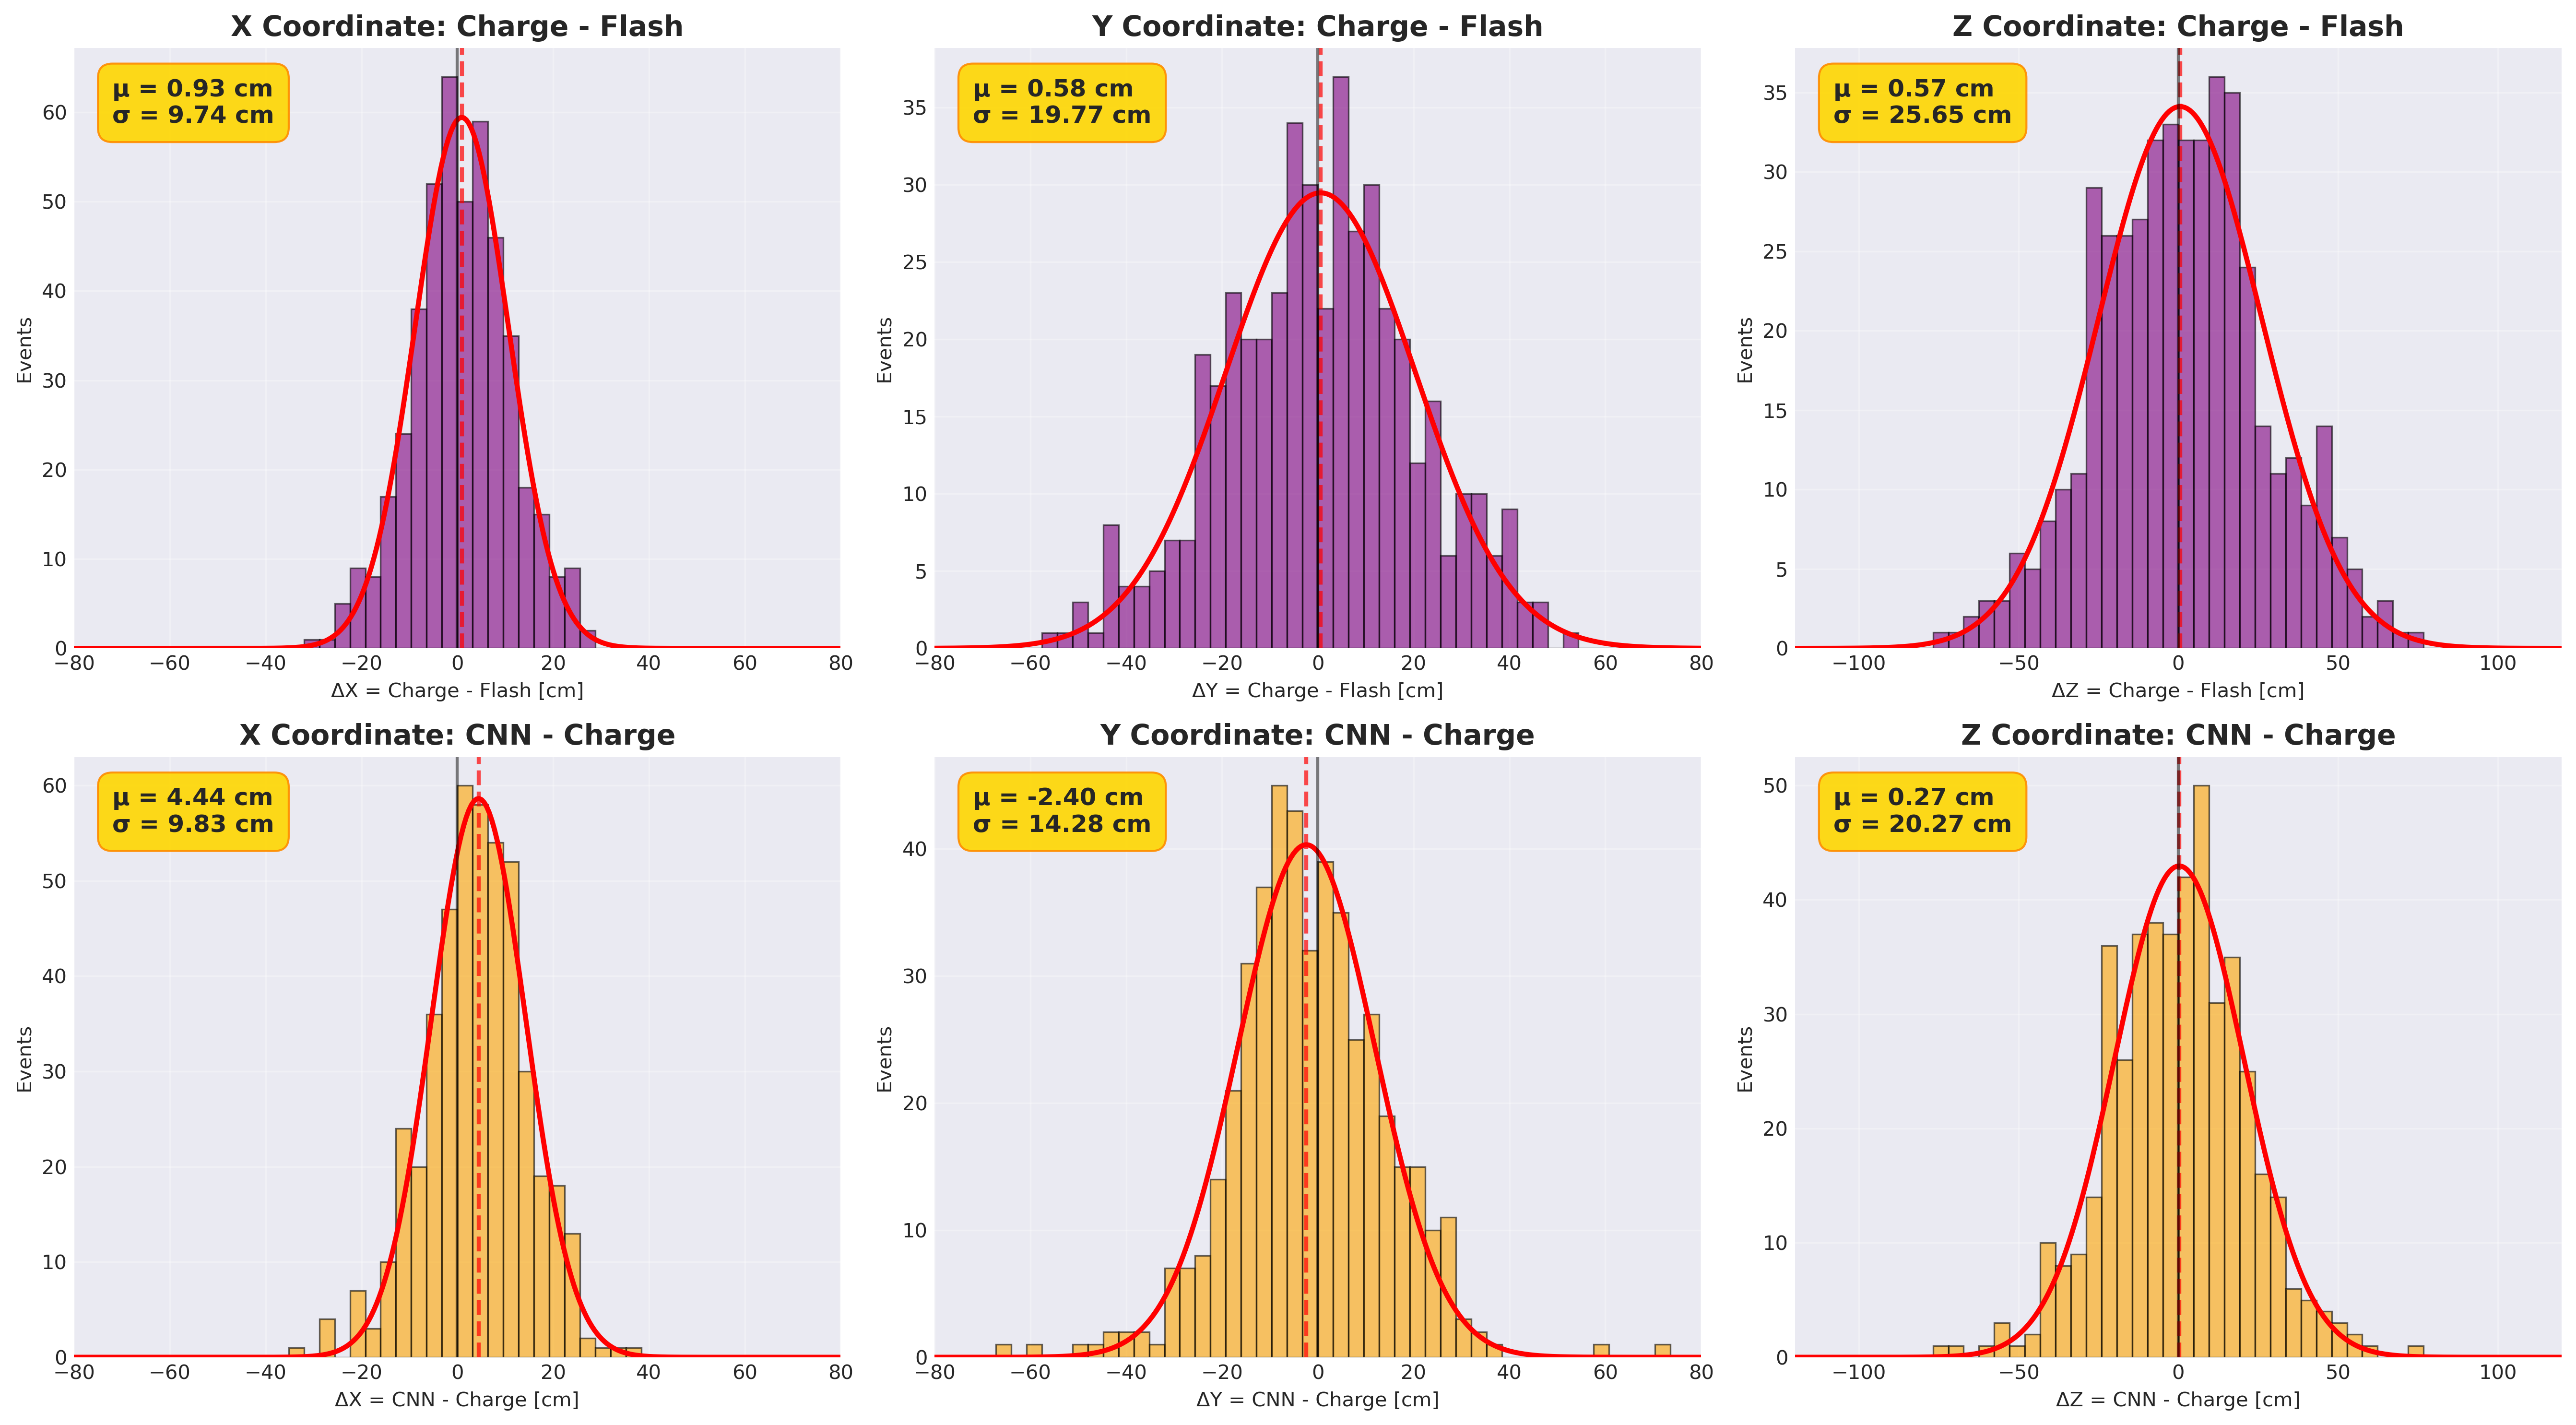

                              GAUSSIAN FIT RESULTS

Comparison                 Coord        Mean μ [cm]       Sigma σ [cm]
----------------------------------------------------------------------------------------------------
Charge - Flash                 X    0.93 ±  0.23    9.74 ±  0.23
Charge - Flash                 Y    0.58 ±  0.86   19.77 ±  0.86
Charge - Flash                 Z    0.57 ±  0.95   25.65 ±  0.95
----------------------------------------------------------------------------------------------------
CNN - Charge                   X    4.44 ±  0.25    9.83 ±  0.25
CNN - Charge                   Y   -2.40 ±  0.47   14.28 ±  0.47
CNN - Charge                   Z    0.27 ±  0.73   20.27 ±  0.73
----------------------------------------------------------------------------------------------------

                    RESOLUTION SUMMARY (σ) + 3D DISTANCE (R)

Comparison                       σ_X        σ_Y        σ_Z       Mean R     Median R
------------------------------------

In [14]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-((x - mean)**2) / (2 * sigma**2))

def fit_and_plot(ax, data, xlim, color, coord, title):
    """Fit gaussian to histogram and plot. Returns fit results dict."""
    counts, bin_edges, _ = ax.hist(data, bins=50, alpha=0.6, color=color, 
                                    edgecolor='black', linewidth=0.8, range=xlim)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    try:
        popt, pcov = curve_fit(gaussian, bin_centers, counts, 
                               p0=[counts.max(), data.mean(), data.std()], maxfev=10000)
        mean_fit, sigma_fit = popt[1], popt[2]
        perr = np.sqrt(np.diag(pcov))
        
        x_fit = np.linspace(xlim[0], xlim[1], 300)
        ax.plot(x_fit, gaussian(x_fit, *popt), 'r-', linewidth=2.5)
        ax.axvline(mean_fit, color='red', linestyle='--', linewidth=2, alpha=0.7)
        
        result = {'mean': mean_fit, 'mean_err': perr[1], 'sigma': sigma_fit, 
                  'sigma_err': perr[2], **dict(zip(['shapiro_stat', 'shapiro_pvalue'], stats.shapiro(data)))}
    except Exception as e:
        print(f"Warning: Fit failed for {title} - {coord}: {e}")
        result = {'mean': data.mean(), 'mean_err': 0, 'sigma': data.std(), 
                  'sigma_err': 0, 'shapiro_stat': 0, 'shapiro_pvalue': 0}
    
    ax.text(0.05, 0.95, f'μ = {result["mean"]:.2f} cm\nσ = {result["sigma"]:.2f} cm',
            transform=ax.transAxes, va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='gold', edgecolor='darkorange', alpha=0.9))
    ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
    ax.set(xlim=xlim, xlabel=f'Δ{coord} = {title} [cm]', ylabel='Events')
    ax.set_title(f'{coord} Coordinate: {title}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    return result

# Config
coords = ['X', 'Y', 'Z']
xlim_fixed = {'X': (-80, 80), 'Y': (-80, 80), 'Z': (-120, 120)}
comparisons = {
    'Charge - Flash': (['diff_charge_flash_x', 'diff_charge_flash_y', 'diff_charge_flash_z'], 'purple'),
    'CNN - Charge': (['diff_cnn_charge_x', 'diff_cnn_charge_y', 'diff_cnn_charge_z'], 'orange')
}

# Fit and plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
fit_results = {}
for row, (name, (cols, color)) in enumerate(comparisons.items()):
    for col, (coord, col_name) in enumerate(zip(coords, cols)):
        fit_results[(name, coord)] = fit_and_plot(axes[row, col], df_valid[col_name].dropna(), 
                                                   xlim_fixed[coord], color, coord, name)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/gaussian_fit_bias.png", dpi=150, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/gaussian_fit_bias.pdf", bbox_inches='tight')
plt.show()

# Calculate R
df_valid['R_charge_flash'] = np.sqrt(df_valid['diff_charge_flash_x']**2 + 
                                      df_valid['diff_charge_flash_y']**2 + 
                                      df_valid['diff_charge_flash_z']**2)
df_valid['R_cnn_charge'] = np.sqrt(df_valid['diff_cnn_charge_x']**2 + 
                                    df_valid['diff_cnn_charge_y']**2 + 
                                    df_valid['diff_cnn_charge_z']**2)

R_stats = {name: {'mean': df_valid[col].mean(), 'std': df_valid[col].std(), 'median': df_valid[col].median()}
           for name, col in [('Charge - Flash', 'R_charge_flash'), ('CNN - Charge', 'R_cnn_charge')]}

# Print results
print("="*100 + "\n" + " "*30 + "GAUSSIAN FIT RESULTS\n" + "="*100)
print(f"\n{'Comparison':25s} {'Coord':>6s} {'Mean μ [cm]':>18s} {'Sigma σ [cm]':>18s}")
print("-"*100)
for name in comparisons:
    for coord in coords:
        r = fit_results[(name, coord)]
        print(f"{name:25s} {coord:>6s} {r['mean']:7.2f} ± {r['mean_err']:5.2f} {r['sigma']:7.2f} ± {r['sigma_err']:5.2f}")
    print("-"*100)

print("\n" + "="*100 + "\n" + " "*20 + "RESOLUTION SUMMARY (σ) + 3D DISTANCE (R)\n" + "="*100)
print(f"\n{'Comparison':25s} {'σ_X':>10s} {'σ_Y':>10s} {'σ_Z':>10s} {'Mean R':>12s} {'Median R':>12s}")
print("-"*100)
for name in comparisons:
    sigmas = [fit_results[(name, c)]['sigma'] for c in coords]
    print(f"{name:25s} {sigmas[0]:>10.2f} {sigmas[1]:>10.2f} {sigmas[2]:>10.2f} {R_stats[name]['mean']:>12.2f} {R_stats[name]['median']:>12.2f}")
print("="*100)

print("\n" + "="*100 + "\n" + " "*25 + "SHAPIRO-WILK NORMALITY TEST\n" + "="*100)
print("\nH0: Data comes from a normal distribution (p > 0.05 = Normal)\n")
print(f"{'Comparison':25s} {'Coord':>6s} {'Statistic':>12s} {'p-value':>12s} {'Normal?':>10s}")
print("-"*100)
for name in comparisons:
    for coord in coords:
        r = fit_results[(name, coord)]
        is_normal = "Yes" if r['shapiro_pvalue'] > 0.05 else "No"
        print(f"{name:25s} {coord:>6s} {r['shapiro_stat']:>12.4f} {r['shapiro_pvalue']:>12.4f} {is_normal:>10s}")
    print("-"*100)
print("="*100)

#### Per TPC

Total events: 461
Events TPC 0: 251 (54.4%)
Events TPC 1: 210 (45.6%)


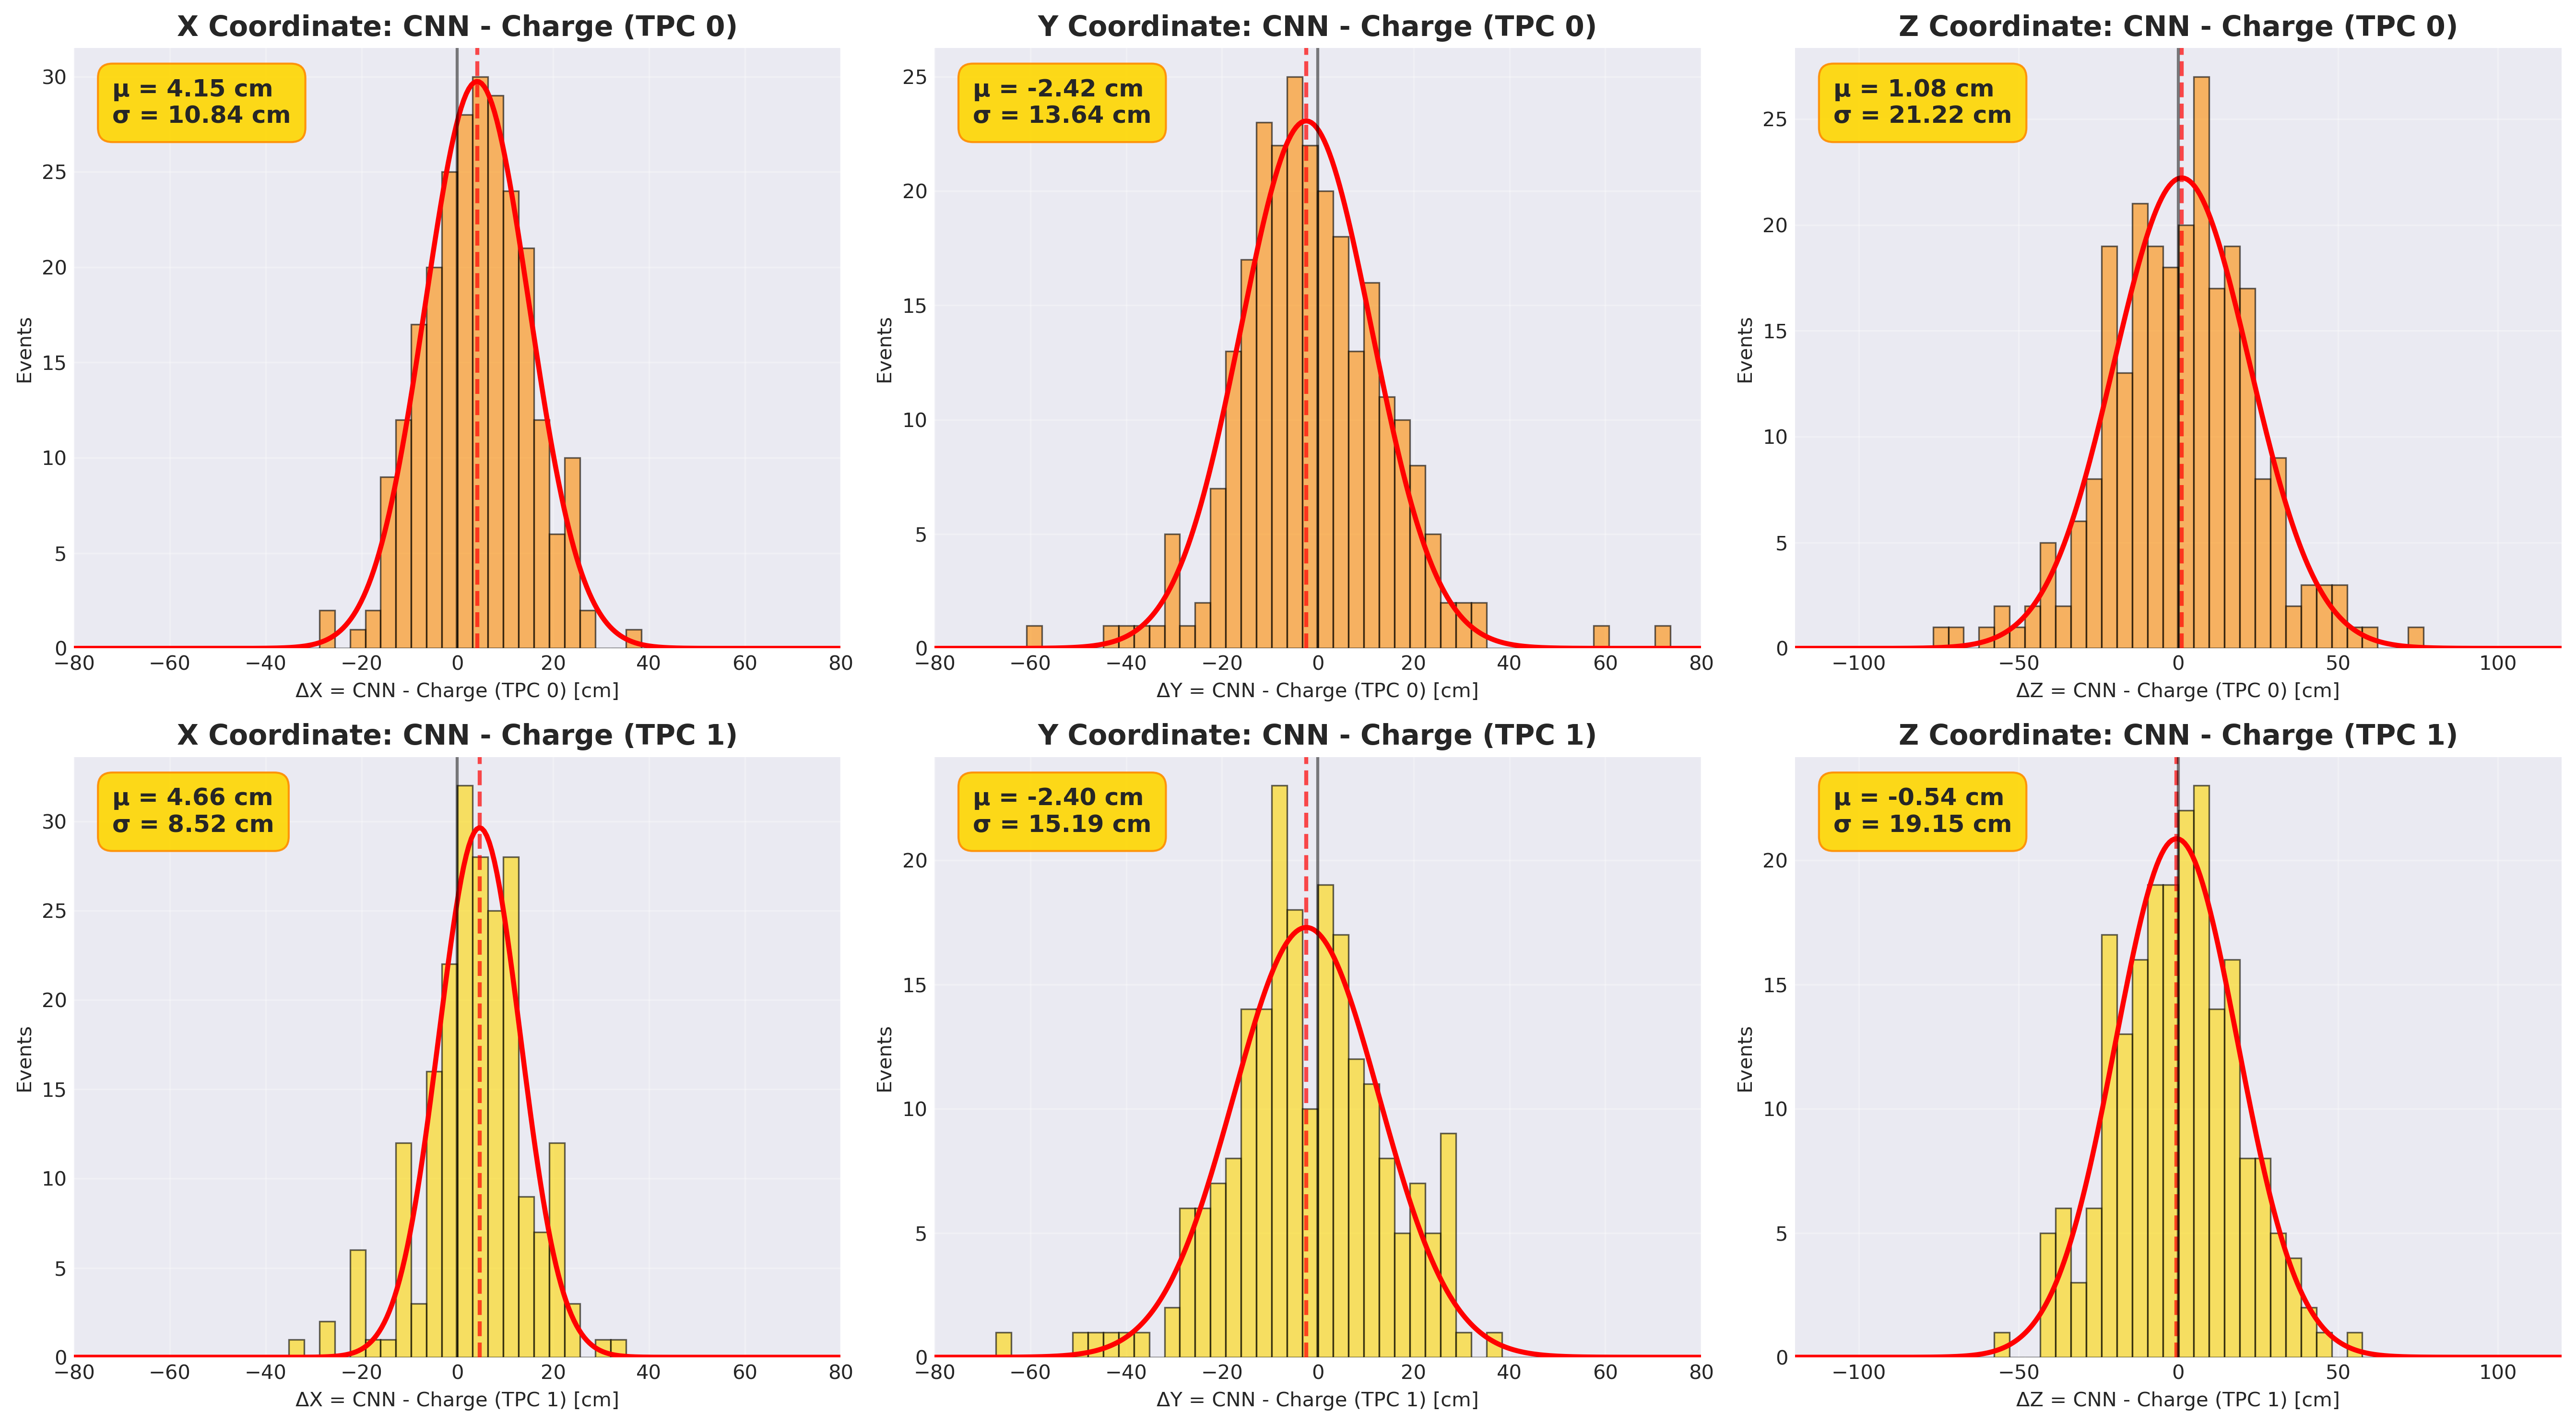


                              3D DISTANCE (R) BY TPC

TPC            Mean R [cm]      Std R [cm]   Median R [cm]        N events
----------------------------------------------------------------------------------------------------
TPC 0                26.76           16.20           22.94             251
TPC 1                26.15           22.30           22.74             210

                              GAUSSIAN FIT RESULTS BY TPC

TPC           Coord        Mean μ [cm]       Sigma σ [cm]     N events
----------------------------------------------------------------------------------------------------
TPC 0             X    4.15 ±  0.24   10.84 ±  0.24          251
TPC 0             Y   -2.42 ±  0.49   13.64 ±  0.49          251
TPC 0             Z    1.08 ±  0.94   21.22 ±  0.94          251
----------------------------------------------------------------------------------------------------
TPC 1             X    4.66 ±  0.47    8.52 ±  0.47          210
TPC 1             Y   -2.4

In [15]:
# Config
coords = ['X', 'Y', 'Z']
xlim_fixed = {'X': (-80, 80), 'Y': (-80, 80), 'Z': (-120, 120)}
diff_cols = ['diff_cnn_charge_x', 'diff_cnn_charge_y', 'diff_cnn_charge_z']

# Separate by TPC
df_tpc0 = df_valid[df_valid['selected_tpc'] == 0].copy()
df_tpc1 = df_valid[df_valid['selected_tpc'] == 1].copy()
tpc_data = {0: (df_tpc0, 'darkorange'), 1: (df_tpc1, 'gold')}

print(f"Total events: {len(df_valid)}")
print(f"Events TPC 0: {len(df_tpc0)} ({100*len(df_tpc0)/len(df_valid):.1f}%)")
print(f"Events TPC 1: {len(df_tpc1)} ({100*len(df_tpc1)/len(df_valid):.1f}%)")

# Fit and plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
fit_results_by_tpc = {}
for row, (tpc, (df_tpc, color)) in enumerate(tpc_data.items()):
    for col, (coord, diff_col) in enumerate(zip(coords, diff_cols)):
        result = fit_and_plot(axes[row, col], df_tpc[diff_col].dropna(), 
                              xlim_fixed[coord], color, coord, f'CNN - Charge (TPC {tpc})')
        result['n_events'] = len(df_tpc)
        fit_results_by_tpc[(tpc, coord)] = result
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/gaussian_fit_bias_per_tpc.png", dpi=150, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/gaussian_fit_bias_per_tpc.pdf", bbox_inches='tight')
plt.show()

# Calculate R by TPC
for tpc, (df_tpc, _) in tpc_data.items():
    df_tpc['R_cnn_charge'] = np.sqrt(df_tpc['diff_cnn_charge_x']**2 + 
                                      df_tpc['diff_cnn_charge_y']**2 + 
                                      df_tpc['diff_cnn_charge_z']**2)

R_stats_tpc = {tpc: {'mean': tpc_data[tpc][0]['R_cnn_charge'].mean(),
                     'std': tpc_data[tpc][0]['R_cnn_charge'].std(),
                     'median': tpc_data[tpc][0]['R_cnn_charge'].median()}
               for tpc in [0, 1]}

# Print results
print("\n" + "="*100 + "\n" + " "*30 + "3D DISTANCE (R) BY TPC\n" + "="*100)
print(f"\n{'TPC':10s} {'Mean R [cm]':>15s} {'Std R [cm]':>15s} {'Median R [cm]':>15s} {'N events':>15s}")
print("-"*100)
for tpc in [0, 1]:
    r = R_stats_tpc[tpc]
    print(f"{'TPC ' + str(tpc):10s} {r['mean']:>15.2f} {r['std']:>15.2f} {r['median']:>15.2f} {len(tpc_data[tpc][0]):>15d}")
print("="*100)

print("\n" + "="*100 + "\n" + " "*30 + "GAUSSIAN FIT RESULTS BY TPC\n" + "="*100)
print(f"\n{'TPC':10s} {'Coord':>8s} {'Mean μ [cm]':>18s} {'Sigma σ [cm]':>18s} {'N events':>12s}")
print("-"*100)
for tpc in [0, 1]:
    for coord in coords:
        r = fit_results_by_tpc[(tpc, coord)]
        print(f"{'TPC ' + str(tpc):10s} {coord:>8s} {r['mean']:7.2f} ± {r['mean_err']:5.2f} {r['sigma']:7.2f} ± {r['sigma_err']:5.2f} {r['n_events']:>12d}")
    print("-"*100)
print("="*100)

print("\n" + "="*100 + "\n" + " "*20 + "RESOLUTION SUMMARY (σ) + 3D DISTANCE (R) BY TPC\n" + "="*100)
print(f"\n{'TPC':10s} {'σ_X [cm]':>12s} {'σ_Y [cm]':>12s} {'σ_Z [cm]':>12s} {'Mean R [cm]':>15s} {'Median R [cm]':>15s}")
print("-"*100)
for tpc in [0, 1]:
    sigmas = [fit_results_by_tpc[(tpc, c)]['sigma'] for c in coords]
    print(f"{'TPC ' + str(tpc):10s} {sigmas[0]:>12.2f} {sigmas[1]:>12.2f} {sigmas[2]:>12.2f} {R_stats_tpc[tpc]['mean']:>15.2f} {R_stats_tpc[tpc]['median']:>15.2f}")
print("="*100)

print("\n" + "="*100 + "\n" + " "*25 + "SHAPIRO-WILK NORMALITY TEST BY TPC\n" + "="*100)
print("\nH0: Data comes from a normal distribution (p > 0.05 = Normal)\n")
print(f"{'TPC':10s} {'Coord':>8s} {'Statistic':>12s} {'p-value':>12s} {'Normal?':>10s}")
print("-"*100)
for tpc in [0, 1]:
    for coord in coords:
        r = fit_results_by_tpc[(tpc, coord)]
        is_normal = "Yes" if r['shapiro_pvalue'] > 0.05 else "No"
        print(f"{'TPC ' + str(tpc):10s} {coord:>8s} {r['shapiro_stat']:>12.4f} {r['shapiro_pvalue']:>12.4f} {is_normal:>10s}")
    print("-"*100)
print("="*100)

### 3D distance error distribution

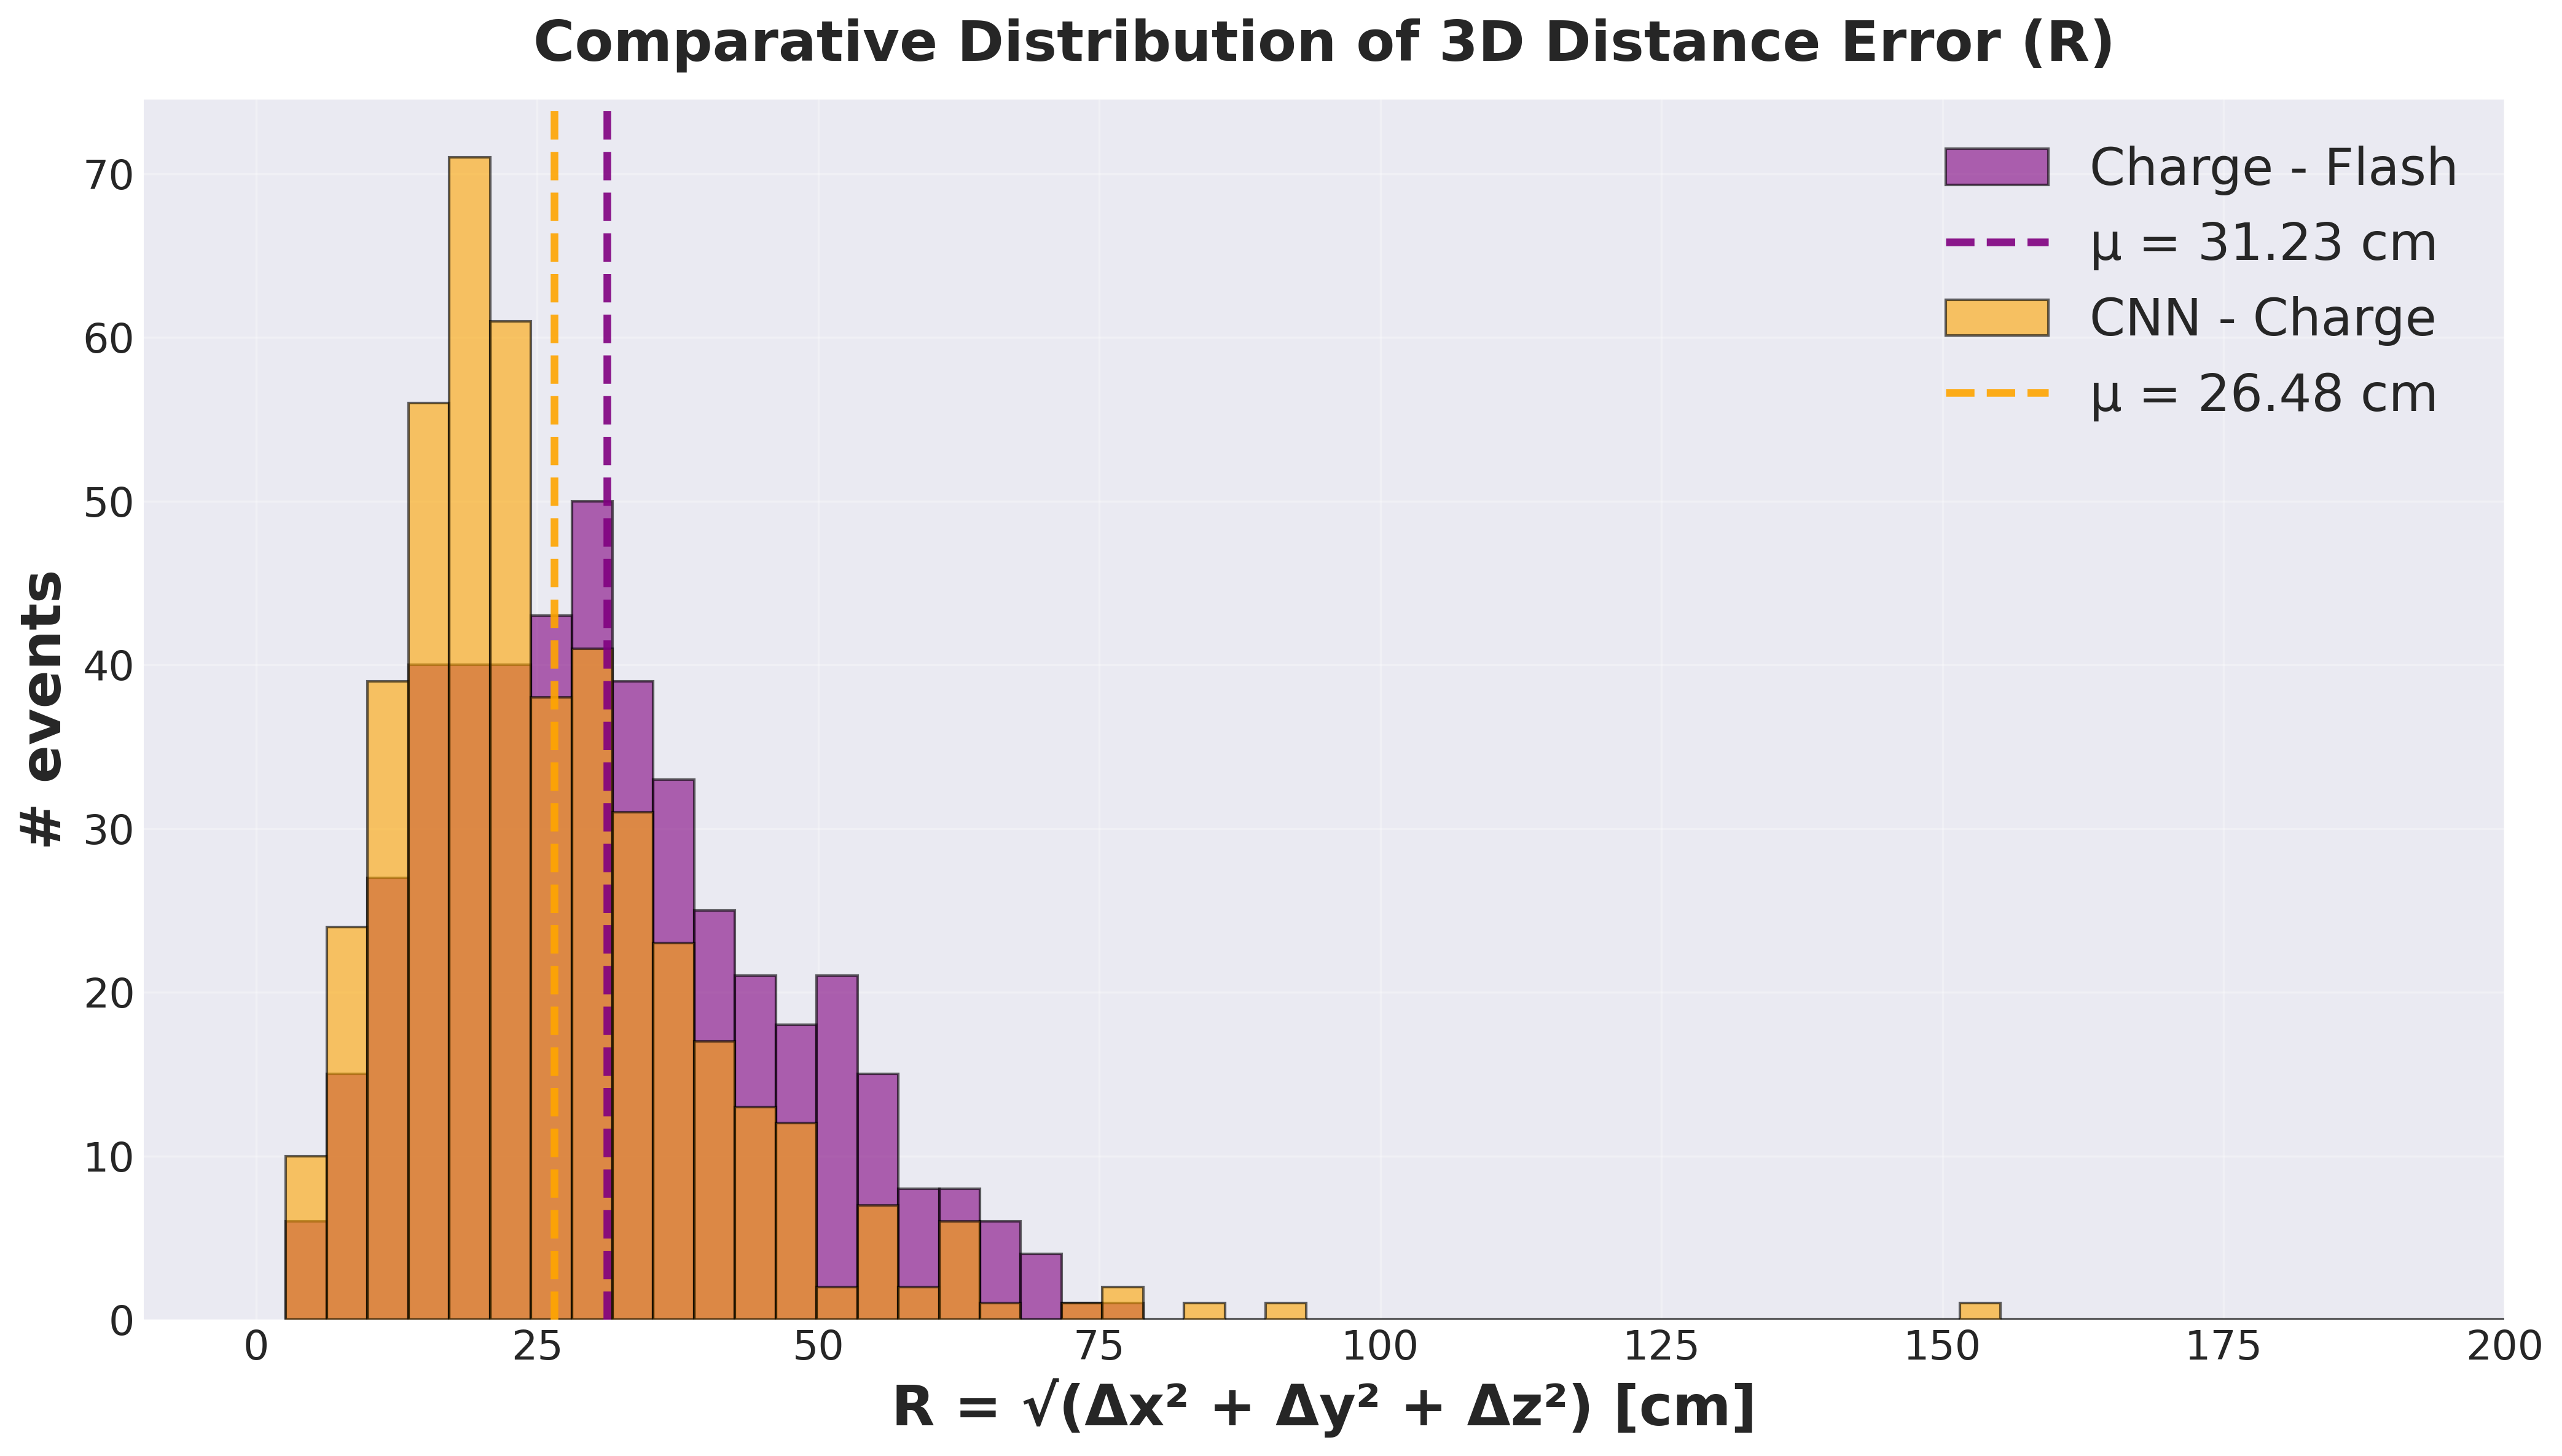

                                   3D DISTANCE PERCENTILES (R)

Comparison                            P50 [cm]        P68 [cm]        P90 [cm]        P95 [cm]        P98 [cm]
--------------------------------------------------------------------------------------------------------------
Charge - Flash                           29.59           36.53           52.28           59.26           65.22
CNN - Charge                             22.86           29.43           43.95           52.58           62.97


In [16]:
# Comparative plot of 3D distance distributions (R)
fig, ax = plt.subplots(1, 1, figsize=(14, 8), dpi=300) 

# R data for each comparison
R_data = {
    'Charge - Flash': (df_valid['R_charge_flash'], 'purple'),
    'CNN - Charge': (df_valid['R_cnn_charge'], 'orange')
}

# Find common range for bins
all_R_data = pd.concat([df_valid['R_charge_flash'], 
                        df_valid['R_cnn_charge']])
min_R = all_R_data.min()
max_R = all_R_data.max()

# Create common bins
bins_common = np.linspace(min_R, max_R, 80)

for name, (data, color) in R_data.items():
    # Calculate statistics
    mean_r = data.mean()
    
    # Histogram with better visibility
    ax.hist(data, bins=bins_common, alpha=0.6, color=color, 
            label=f'{name}',
            edgecolor='black', linewidth=1.0, density=False)
    
    # Vertical line for mean (with label in legend)
    ax.axvline(mean_r, color=color, linestyle='--', linewidth=3, alpha=0.9, 
               label=f'μ = {mean_r:.2f} cm') 

# Plot title
ax.set_title('Comparative Distribution of 3D Distance Error (R)', fontsize=22, fontweight='bold', pad=15)

# Axis labels
ax.set_xlabel('R = √(Δx² + Δy² + Δz²) [cm]', fontsize=22, fontweight='bold') 
ax.set_ylabel('# events', fontsize=22, fontweight='bold') 

# Legend
ax.legend(fontsize=20, loc='upper right') 

# Tick labels
ax.tick_params(axis='both', which='major', labelsize=16) 

ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 200)

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/3d_distance_distribution.png", dpi=150, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/3d_distance_distribution.pdf", bbox_inches='tight')
plt.show() 


# Percentiles
print("="*110)
print(" "*35 + "3D DISTANCE PERCENTILES (R)")
print("="*110)
print(f"\n{'Comparison':30s} {'P50 [cm]':>15s} {'P68 [cm]':>15s} {'P90 [cm]':>15s} {'P95 [cm]':>15s} {'P98 [cm]':>15s}")
print("-"*(30+5*15 + 5))

for name, (data, _) in R_data.items():
    p50 = data.median()
    p68 = np.percentile(data, 68)
    p90 = np.percentile(data, 90)
    p95 = np.percentile(data, 95)
    p98 = np.percentile(data, 98)
    print(f"{name:30s} {p50:>15.2f} {p68:>15.2f} {p90:>15.2f} {p95:>15.2f} {p98:>15.2f}")

print("="*110)

Valid rows for angle comparison: 461 / 461


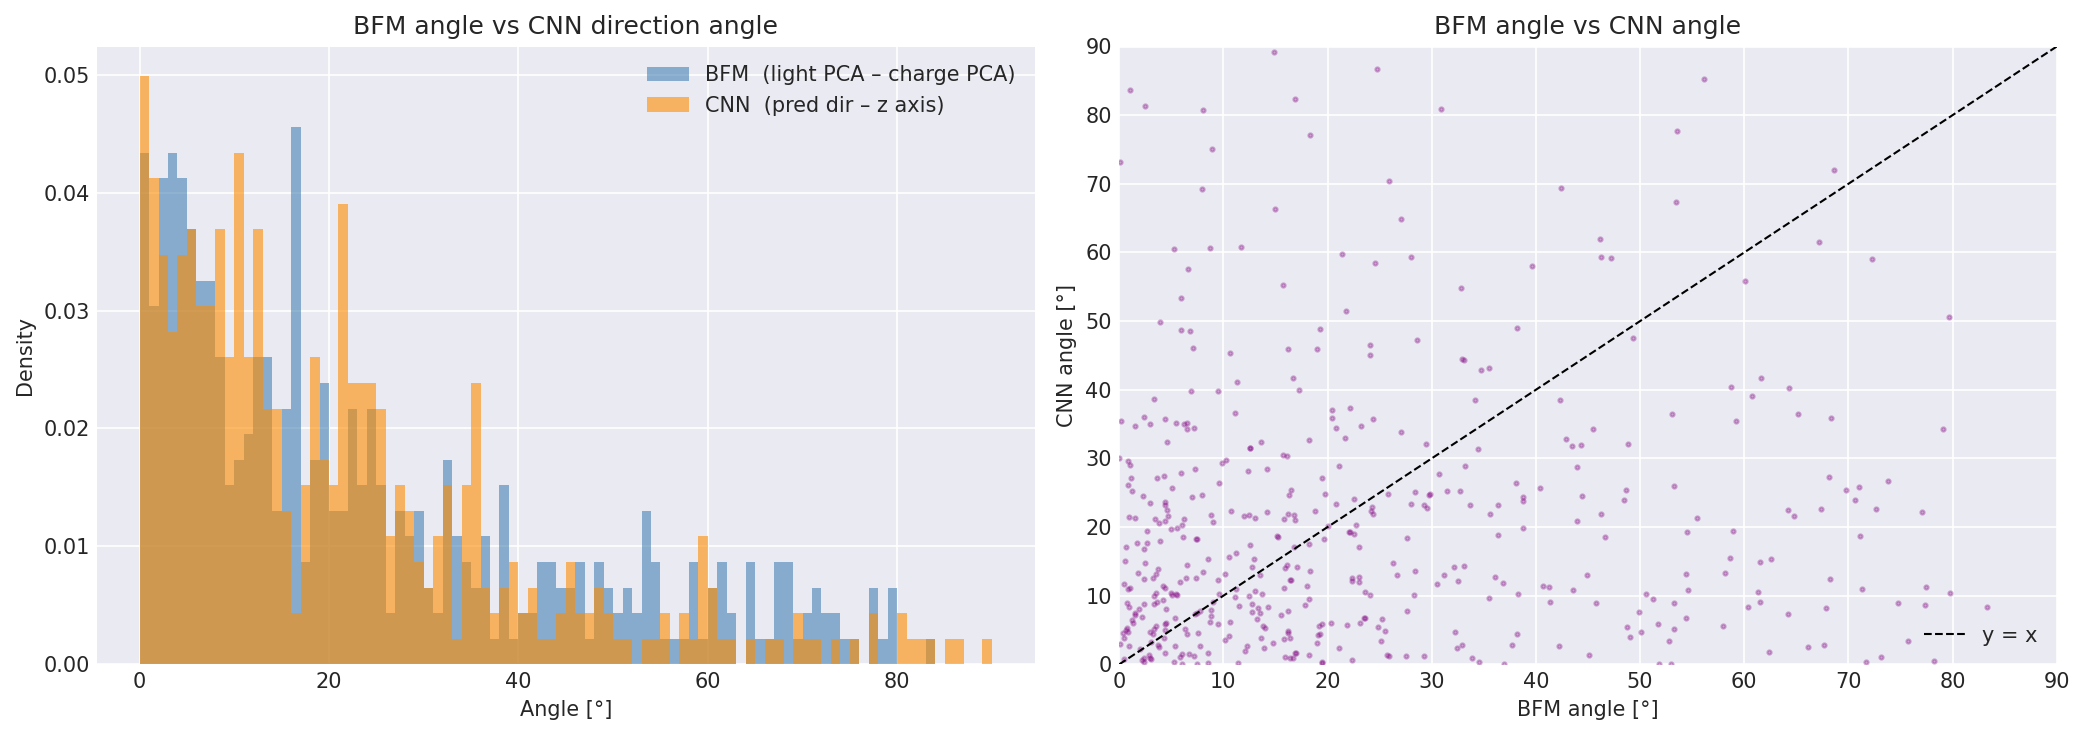


BFM angle  — mean: 23.6°  std: 21.0°
CNN angle  — mean: 20.7°  std: 18.6°


In [17]:
# Comparison: BFM angle vs CNN direction angle
# BFM angle  = angle(lightPCAYZ, chargePCAYZ) — stored in 'angle'
# CNN angle  = angle of pred_dir w.r.t. z-axis: arccos(|pred_dir_z|) in degrees

# Filter rows with valid values
valid = (
    (df_valid['angle']      != -9999) &
    (df_valid['pred_dir_y'] != -9999) &
    (df_valid['pred_dir_z'] != -9999)
)
df_angles = df_valid[valid].copy()
print(f"Valid rows for angle comparison: {len(df_angles)} / {len(df_valid)}")

# Compute CNN direction angle w.r.t. z-axis in YZ plane
mag_cnn = np.sqrt(df_angles['pred_dir_y']**2 + df_angles['pred_dir_z']**2)
df_angles['cnn_angle'] = np.degrees(
    np.arccos(np.clip(df_angles['pred_dir_z'].abs() / mag_cnn, -1, 1))
)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

bins = np.linspace(0, 90, 91)

# Left: overlapping histograms
ax = axes[0]
ax.hist(df_angles['angle'],     bins=bins, alpha=0.6, color='steelblue',
        label='BFM  (light PCA – charge PCA)', density=True)
ax.hist(df_angles['cnn_angle'], bins=bins, alpha=0.6, color='darkorange',
        label='CNN  (pred dir – z axis)',  density=True)
ax.set_xlabel('Angle [°]')
ax.set_ylabel('Density')
ax.set_title('BFM angle vs CNN direction angle')
ax.legend()

# Right: scatter BFM angle vs CNN angle
ax = axes[1]
ax.scatter(df_angles['angle'], df_angles['cnn_angle'], s=4, alpha=0.3, color='purple')
ax.plot([0, 90], [0, 90], 'k--', lw=1, label='y = x')
ax.set_xlabel('BFM angle [°]')
ax.set_ylabel('CNN angle [°]')
ax.set_title('BFM angle vs CNN angle')
ax.set_xlim(0, 90)
ax.set_ylim(0, 90)
ax.legend()

plt.tight_layout()
fig.savefig(f"{FIG_DIR}/angle_comparison.png", dpi=150, bbox_inches='tight')
fig.savefig(f"{FIG_DIR}/angle_comparison.pdf", bbox_inches='tight')
plt.show()

print(f"\nBFM angle  — mean: {df_angles['angle'].mean():.1f}°  std: {df_angles['angle'].std():.1f}°")
print(f"CNN angle  — mean: {df_angles['cnn_angle'].mean():.1f}°  std: {df_angles['cnn_angle'].std():.1f}°")